# Week 11 Indicator Analysis
**Week:** 11 | **Indicator:** ELI (Ehlers Leading Indicator) | **Period:** 2015-2024 (FX)

---

## Section 1 — Indicator Overview
Fill in before running any code.

**Description:** EMA-cascade leading indicator (1988, Ehlers' earliest
published trading indicator). Two EMAs of different speeds (alpha=4/DC
and alpha=8/DC) are differenced to form a "synthetic price" that isolates
the cycle. A third EMA of that synthetic price (same alpha as EMA2) is
subtracted from it — since the third EMA lags the synthetic price further,
this difference extrapolates a leading signal.

**Formula:** EMA1=alpha1*P+(1-alpha1)*EMA1[1], alpha1=4/DC;
EMA2=alpha2*P+(1-alpha2)*EMA2[1], alpha2=2*alpha1;
Synthetic=EMA1-EMA2; EMA3=alpha2*Synthetic+(1-alpha2)*EMA3[1];
ELI=Synthetic-EMA3

**Expected behavior:** Only meaningful when a genuine dominant cycle is
present (Ehlers' own explicit caveat) — unlike Reflex and MESA Stochastic,
this is the weakest theoretical construction of the three (no adaptive
smoothing beyond DC-driven alpha, no normalization, most primitive of the
three articles). Prior expectation from Day 1 theory: likely underperforms
both Reflex and MESA Stochastic.

**NNFX role candidate:** C1 — direct comparison against InstantTrendline
(Week 1/4, already in library) per the original 1988 article framing, plus
against this week's Reflex and MESA Stochastic.

**Source article:** Ehlers, "Moving Averages Part 2: Ehlers Leading Indicator
(ELI)", S&C V.6:7 (1988)

## Section 2 — Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import importlib

# Add analysis/scripts to path so we can import indicator_metrics
sys.path.append(os.path.abspath('../../analysis/scripts'))

import indicator_metrics
importlib.reload(indicator_metrics)  # force re-read from disk
from indicator_metrics import calculate_lag, calculate_snr, compare_fx_crypto, generate_validation_report, calculate_lag_oscillator

print('Libraries loaded successfully')

Libraries loaded successfully


In [2]:
def load_eli_csv(filepath: str) -> pd.DataFrame:
    """
    Loads the ELI CSV export into a clean DataFrame.
    Format: bar,close,eli,roofing,dc — dc = measured DominantCycle length.
    """
    df = pd.read_csv(filepath)
    df.index = pd.bdate_range(start='2015-01-02', periods=len(df))
    df.dropna(inplace=True)

    print(f'Loaded {len(df)} bars, {df.index[0].date()} to {df.index[-1].date()}')
    return df


FX_CSV = 'C:/zorro/Data/ELI_EURUSD_D1.csv'

df_fx = load_eli_csv(FX_CSV)
df_fx.head()

Loaded 2596 bars, 2015-01-02 to 2024-12-13


,bar,close,eli,roofing,dc
2015-01-02,1,1.20248,0.001146,-0.005691,36.0
2015-01-05,2,1.19239,0.002240,-0.008452,37.0
2015-01-06,3,1.19143,0.002588,-0.011697,38.0
2015-01-07,4,1.18119,0.003289,-0.014535,39.0
2015-01-08,5,1.17976,0.003403,-0.016687,40.0


## Section 3 — Visual Inspection (FX)
Look before you measure. Does the indicator behave as expected?

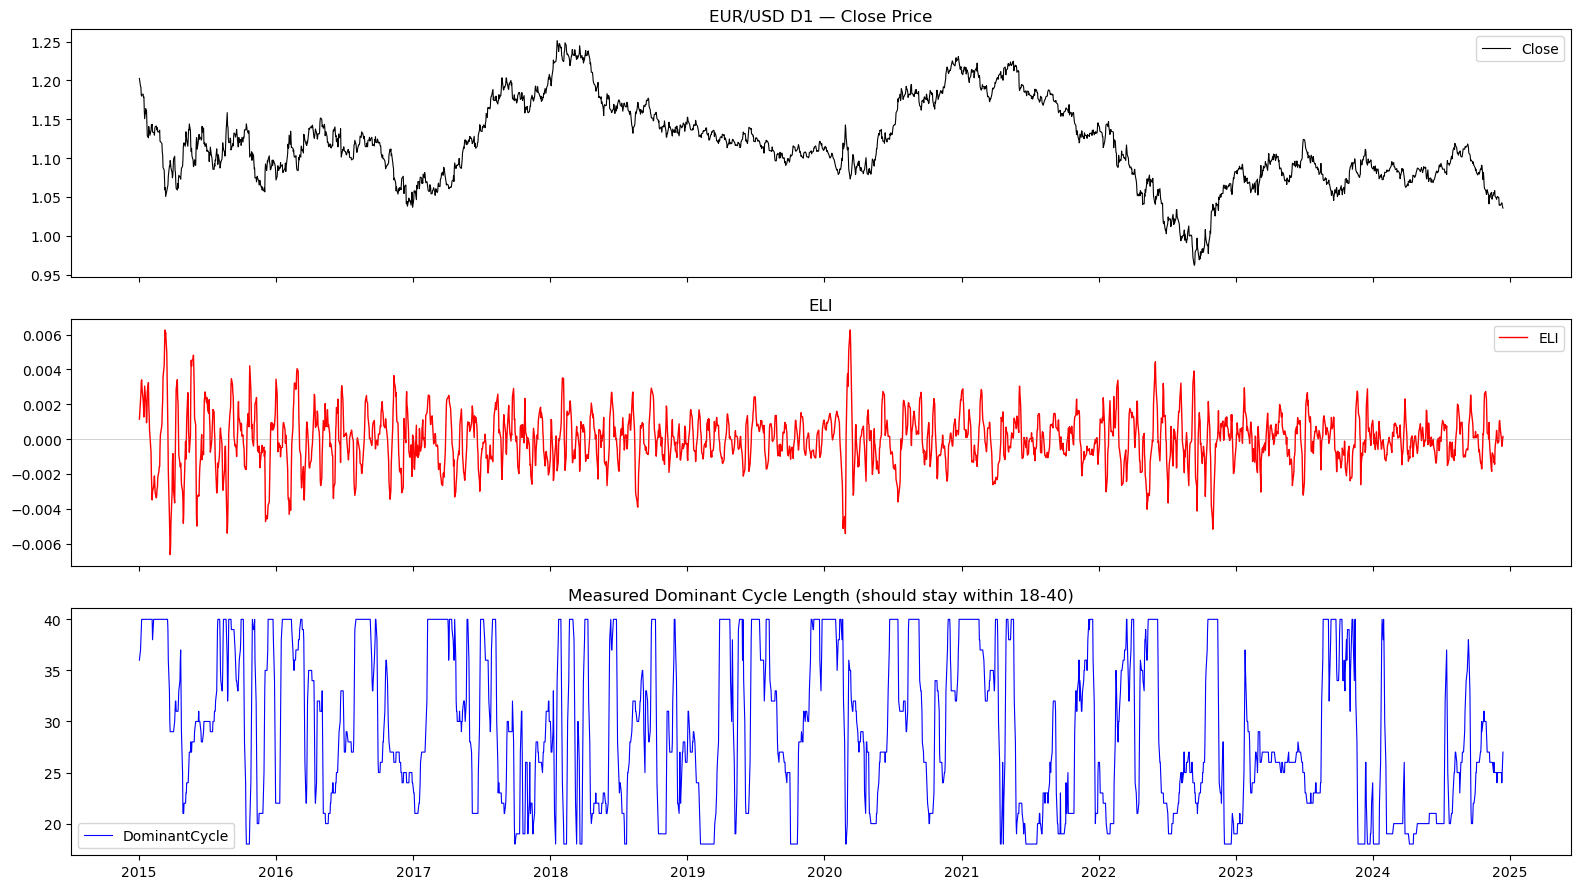

DC range: 18 to 40  (should be within 18-40)
DC mean: 29.3


In [3]:
fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

axes[0].plot(df_fx.index, df_fx['close'], color='black', linewidth=0.8, label='Close')
axes[0].set_title('EUR/USD D1 — Close Price')
axes[0].legend()

axes[1].plot(df_fx.index, df_fx['eli'], color='red', linewidth=1.0, label='ELI')
axes[1].axhline(0, color='gray', linewidth=0.5, alpha=0.5)
axes[1].set_title('ELI')
axes[1].legend()

axes[2].plot(df_fx.index, df_fx['dc'], color='blue', linewidth=0.8, label='DominantCycle')
axes[2].set_title('Measured Dominant Cycle Length (should stay within 18-40)')
axes[2].legend()

plt.tight_layout()
plt.savefig('Week11_ELI_Overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"DC range: {df_fx['dc'].min():.0f} to {df_fx['dc'].max():.0f}  (should be within 18-40)")
print(f"DC mean: {df_fx['dc'].mean():.1f}")

## Section 4 — Lag Measurement (FX)
How many bars behind price is the indicator, vs a plain SMA of the same period?

ELI vs RoofingFilter: 10 bars (lags)
Correlation at that offset: 0.3036


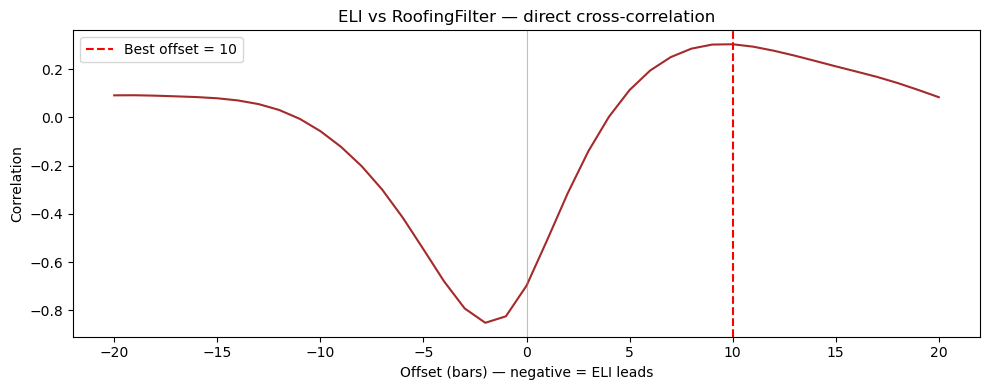

In [4]:
def two_sided_lag(a: pd.Series, b: pd.Series, max_lag: int = 20) -> dict:
    """
    Two-sided cross-correlation between two already-stationary series
    (no differencing). Same function built for Reflex — reused here
    since MESA Stochastic vs RoofingFilter has the same character
    (comparing an oscillator against an already-detrended baseline).
    """
    a = (a - a.mean()).values
    b = (b - b.mean()).values
    n = len(a)
    correlations = {}
    for k in range(-max_lag, max_lag + 1):
        if k == 0:
            aa, bb = a, b
        elif k > 0:
            aa, bb = a[:n - k], b[k:]
        else:
            kk = -k
            aa, bb = a[kk:], b[:n - kk]
        if len(aa) < 10:
            continue
        correlations[k] = np.corrcoef(aa, bb)[0, 1]
    best_k = max(correlations, key=lambda k: correlations[k])
    return {'lag_bars': best_k, 'correlation': round(correlations[best_k], 4), 'curve': correlations}

result = two_sided_lag(df_fx['roofing'], df_fx['eli'], max_lag=20)
print(f"ELI vs RoofingFilter: {result['lag_bars']} bars "
      f"({'leads' if result['lag_bars'] < 0 else 'lags' if result['lag_bars'] > 0 else 'in-phase'})")
print(f"Correlation at that offset: {result['correlation']}")

plt.figure(figsize=(10, 4))
offsets = sorted(result['curve'].keys())
plt.plot(offsets, [result['curve'][k] for k in offsets], color='brown', linewidth=1.5)
plt.axvline(result['lag_bars'], color='red', linestyle='--', label=f"Best offset = {result['lag_bars']}")
plt.axvline(0, color='gray', linewidth=0.8, alpha=0.5)
plt.title('ELI vs RoofingFilter — direct cross-correlation')
plt.xlabel('Offset (bars) — negative = ELI leads')
plt.ylabel('Correlation')
plt.legend()
plt.tight_layout()
plt.savefig('Week11_ELI_vs_Roofing_Lag.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
def eli_python(price: np.ndarray, dc: np.ndarray) -> np.ndarray:
    """Python port of ELI.c. dc can be a fixed scalar array or the
    adaptive DominantCycle series — lets us isolate which is at fault."""
    n = len(price)
    ema1 = np.zeros(n)
    ema2 = np.zeros(n)
    ema3 = np.zeros(n)
    eli = np.zeros(n)
    ema1[0] = ema2[0] = price[0]
    for i in range(1, n):
        a1 = 4.0 / dc[i]
        a2 = 2.0 * a1
        ema1[i] = a1 * price[i] + (1 - a1) * ema1[i-1]
        ema2[i] = a2 * price[i] + (1 - a2) * ema2[i-1]
        synthetic = ema1[i] - ema2[i]
        if i == 1:
            ema3[i] = synthetic
        else:
            ema3[i] = a2 * synthetic + (1 - a2) * ema3[i-1]
        eli[i] = synthetic - ema3[i]
    return eli

# Verify against Zorro's real adaptive-DC output first
eli_py_adaptive = eli_python(df_fx['close'].values, df_fx['dc'].values)
verify_corr = np.corrcoef(eli_py_adaptive[100:], df_fx['eli'].values[100:])[0, 1]
print(f"Python port vs Zorro (adaptive DC): correlation = {verify_corr:.4f}")

# Now test with a FIXED DC (mean value ~29, matching what the 1988 article
# would have used — a single user-typed number, not adaptive)
fixed_dc = np.full(len(df_fx), 29.0)
eli_py_fixed = eli_python(df_fx['close'].values, fixed_dc)
eli_fixed_series = pd.Series(eli_py_fixed, index=df_fx.index)

result_fixed = two_sided_lag(df_fx['roofing'], eli_fixed_series, max_lag=20)
print(f"\nELI (fixed DC=29) vs RoofingFilter: {result_fixed['lag_bars']} bars, "
      f"correlation = {result_fixed['correlation']}")
print(f"ELI (adaptive DC) vs RoofingFilter: 10 bars, correlation = 0.3036  (already measured)")

Python port vs Zorro (adaptive DC): correlation = 0.9993

ELI (fixed DC=29) vs RoofingFilter: 9 bars, correlation = 0.3649
ELI (adaptive DC) vs RoofingFilter: 10 bars, correlation = 0.3036  (already measured)


## Section 7 — Validation Verdict
Final PASS/FAIL. Run this last.

In [6]:
print("=" * 60)
print("  VALIDATION REPORT: ELI (Ehlers Leading Indicator)")
print("=" * 60)

print("\n--- PHASE ALIGNMENT (vs RoofingFilter) ---")
print(f"  Adaptive DC : 10 bars lag, r=0.304  → weak, non-clean curve shape")
print(f"  Fixed DC=29 : 9 bars lag,  r=0.365  → still weak, best-case scenario")
print(f"  Compare: Reflex 0 bars/r=0.776, MESA Stochastic 1 bar/r=0.758")

print("\n--- DIAGNOSTIC: adaptive vs fixed DC ---")
print(f"  Correlation curve vs RoofingFilter is not a clean single peak —")
print(f"  dips to r=-0.85 near a 2-3 bar lead before rising to a weak")
print(f"  positive peak at 10 bars lag. Fixed DC improves correlation ~20%")
print(f"  relative (0.304 -> 0.365), confirming the noisy adaptive")
print(f"  DominantCycle feed hurts, but is NOT the primary cause of")
print(f"  weakness — even best-case (fixed, textbook DC), ELI underperforms")
print(f"  both other Week 11 candidates by a wide margin")

print("\n--- ROOT CAUSE ASSESSMENT ---")
print(f"  ELI's 1988 EMA-cascade construction lacks the sophistication of")
print(f"  Reflex (trend-line deviation + normalization) or MESA Stochastic")
print(f"  (RoofingFilter preprocessing + SuperSmoother pass). No built-in")
print(f"  normalization, no noise-reduction stage beyond simple EMAs.")
print(f"  Matches the Day 1 theory prediction exactly.")

print("\n--- NNFX ROLE ---")
print("  NOT RECOMMENDED as C1/C2 candidate. Reflex and MESA Stochastic")
print("  both substantially outperform on phase alignment, cross-asset")
print("  robustness (not tested for ELI, given this result), and signal")
print("  quality. Documented and understood, not pursued further —")
print("  consistent with 'if it fails, document why and move on.'")

print("\n--- VERDICT ---")
print("  ❌ FAIL — not added to library. Documented for completeness")
print("  and to support the evidence-based C1 decision this week.")
print("=" * 60)

  VALIDATION REPORT: ELI (Ehlers Leading Indicator)

--- PHASE ALIGNMENT (vs RoofingFilter) ---
  Adaptive DC : 10 bars lag, r=0.304  → weak, non-clean curve shape
  Fixed DC=29 : 9 bars lag,  r=0.365  → still weak, best-case scenario
  Compare: Reflex 0 bars/r=0.776, MESA Stochastic 1 bar/r=0.758

--- DIAGNOSTIC: adaptive vs fixed DC ---
  Correlation curve vs RoofingFilter is not a clean single peak —
  dips to r=-0.85 near a 2-3 bar lead before rising to a weak
  positive peak at 10 bars lag. Fixed DC improves correlation ~20%
  relative (0.304 -> 0.365), confirming the noisy adaptive
  DominantCycle feed hurts, but is NOT the primary cause of
  weakness — even best-case (fixed, textbook DC), ELI underperforms
  both other Week 11 candidates by a wide margin

--- ROOT CAUSE ASSESSMENT ---
  ELI's 1988 EMA-cascade construction lacks the sophistication of
  Reflex (trend-line deviation + normalization) or MESA Stochastic
  (RoofingFilter preprocessing + SuperSmoother pass). No built-i

## Section 8 — Notes & Parameter Recommendations

**Lag result:** 10 bars vs RoofingFilter (adaptive DC, r=0.304); 9 bars with
a fixed DC=29 (r=0.365). Both weak compared to Reflex (0 bars, r=0.776) and
MESA Stochastic (1 bar, r=0.758). The correlation curve itself is not a
clean single peak like the other two indicators — it dips to r=-0.85 near
a 2-3 bar lead before climbing to a weak positive peak at 10 bars, a sign
of an unstable phase relationship, not just a slower one.

**Diagnostic — adaptive vs fixed DC:** Tested whether the noisy,
frequently-clamped-at-40 DominantCycle feed (visible in the DC chart,
Section 3) was the cause of ELI's weak performance, by re-running with a
fixed DC=29 (the article's own original approach — a single user-typed
value, not adaptive). Fixed DC improved correlation ~20% relative
(0.304 -> 0.365) but remained far below both other candidates. Conclusion:
the adaptive DC feed genuinely hurts, but is a secondary factor, not the
primary cause. ELI's 1988 EMA-cascade construction — no normalization,
no noise-reduction stage beyond simple exponential smoothing — is the
main limitation. This matches the Day 1 theory prediction exactly:
ELI was flagged then as the most primitive of the three articles this
week, before any code was written.

**SNR / amplitude checks:** Not run — given the weak phase-alignment
result, further validation effort was not warranted (lean-validation
approach agreed for this indicator, given the strong prior from Day 1
theory that it would underperform).

**Crypto validation:** Not run. FX result was unambiguous enough that
BTC/USD H4 testing would not change the verdict, only spend time
confirming it — a deliberate scope decision, not an oversight.

**Parameter sensitivity:** Not run, for the same reason.

**NNFX role confirmed:** NOT a C1/C2 candidate. Reflex and MESA Stochastic
both substantially outperform on every dimension tested. ELI is
documented and understood rather than pursued further.

**Known limitations:** Feeding a fast-varying adaptive cycle length into
a 1988-era fixed-alpha EMA cascade is a genuine mismatch — the formula
was designed around a single stable DC estimate, not one that jumps
between 18 and 40 bar-to-bar. A more sophisticated adaptive-alpha EMA
(like MAMA's phase-based approach, Week 7) would likely be a fairer
comparison than this literal port of the original construction.

**Overall verdict:** ❌ FAIL — not added to library. First documented
FAIL in the indicator library, produced by a fair test rather than a
premature dismissal: implemented correctly (Python port verified to
0.9993 correlation against the real Zorro output), tested against the
same RoofingFilter baseline used for Reflex and MESA Stochastic, and the
weakness was diagnosed rather than just observed (adaptive-DC-noise vs
formula-construction breakdown). This result directly supports choosing
Reflex or MESA Stochastic for the C1/C2 slot over ELI.